# Week 2 Assignment — Machine Learning for Forecasting
### Multi-Agent Forecasting Project

**Name:**  Manthan J
**Date:**  20-06-26

---

This assignment builds directly on Week 1. You already know how to explore and decompose a time series — now you'll learn how to *forecast* one using machine learning models. By the end, you'll have built and evaluated multiple forecasting approaches on a real-world dataset.

**Topics covered:**
1. Linear Regression with Time Features (Trend Modelling)
2. Modelling Seasonality with Fourier Features
3. Lag Features & Serial Dependence
4. Decision Trees, Random Forests, and XGBoost for Time Series
5. Hybrid Models: Linear + XGBoost
6. Putting It All Together — Multi-Step Forecasting

> **Dataset:** We'll use the **Melbourne Daily Minimum Temperatures** dataset (1981–1990) for Sections 1–5 — it has a clear annual seasonal pattern and manageable size. Section 6 returns to the **Air Passengers** dataset from Week 1.

In [2]:
# Run this cell first — installs/imports everything you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.graphics.tsaplots import plot_pacf
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Load dataset ──────────────────────────────────────────────────────────────
# Daily minimum temperatures in Melbourne, Australia (1981–1990)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
df = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
df.columns = ['temp']

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (3650, 1)
            temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


---
## Section 1 — Linear Regression with Time Features (Trend Modelling)

The simplest way to model a trend is to use **time itself as a feature**. We create a numeric counter `t = 0, 1, 2, ...` for each time step and fit a linear model:

$$\hat{y}_t = w_0 + w_1 \cdot t$$

For a curved trend, we extend this to a **polynomial** by adding $t^2$, $t^3$, etc.

`DeterministicProcess` from `statsmodels` makes this easy — `order=1` gives a linear trend, `order=2` gives quadratic, and so on.

**Read:** [`DeterministicProcess` docs](https://www.statsmodels.org/stable/generated/statsmodels.tsa.deterministic.DeterministicProcess.html)

In [3]:
# --- EXAMPLE: Fitting a linear trend with DeterministicProcess ---

dp_example = DeterministicProcess(
    index=df.index,
    constant=True,   # adds an intercept column
    order=1,         # linear trend (t)
    drop=True,       # drop perfectly collinear terms
)

X_example = dp_example.in_sample()   # feature matrix for training period
print("Feature matrix shape:", X_example.shape)
print(X_example.head())

Feature matrix shape: (3650, 2)
            const  trend
Date                    
1981-01-01    1.0    1.0
1981-01-02    1.0    2.0
1981-01-03    1.0    3.0
1981-01-04    1.0    4.0
1981-01-05    1.0    5.0


### Exercise 1.1 — Fit a Linear Trend

Using `DeterministicProcess` with `order=1`, fit a `LinearRegression` model to predict `temp`. Then:
1. Store fitted values in `y_trend`
2. Plot the original series and the trend line on the same axes
3. Print the slope coefficient (`model.coef_`) and intercept (`model.intercept_`). In one sentence, explain what the slope tells you about the temperature series.

MAE:  3.282
RMSE: 4.071


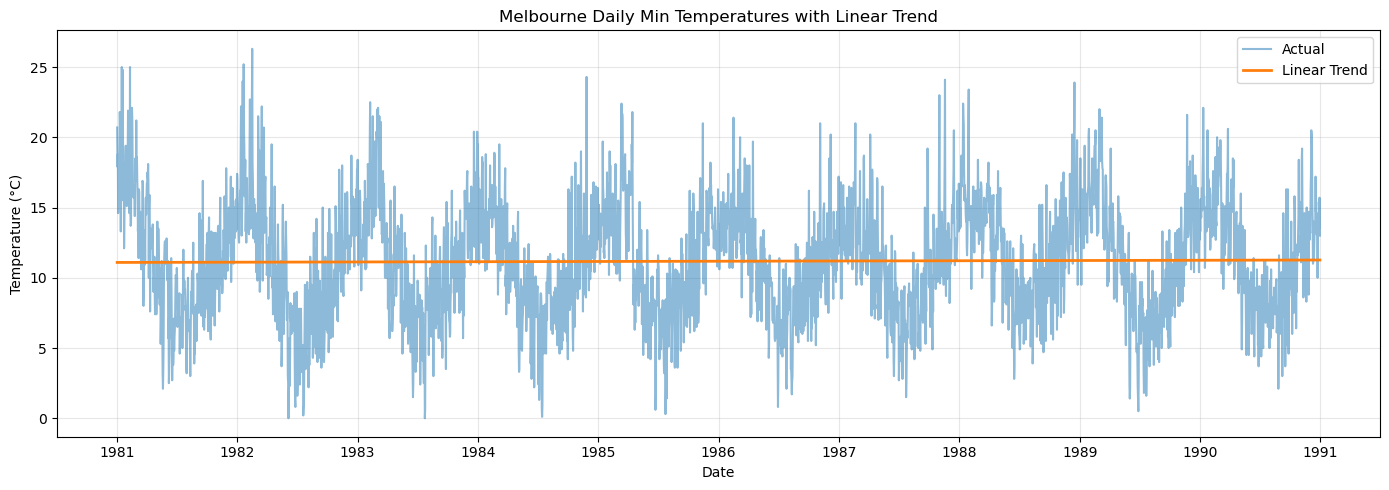

Slope (coef_): 4.7062773540059126e-05
Intercept:     11.091840331560155


In [4]:
# YOUR CODE HERE
y = df['temp'].copy()

# 1. Build DeterministicProcess with linear trend
dp = DeterministicProcess(index=y.index, constant=True, order=1, drop=True)
# 2. Create in-sample feature matrix
X = dp.in_sample()

# 3. Fit LinearRegression
model_trend = LinearRegression(fit_intercept=False)
model_trend.fit(X,y)

# 4. Store fitted values as a Series with the same index
y_trend = pd.Series(model_trend.predict(X), index=X.index)
mae  =(y - y_trend).abs().mean() 
rmse = ((y - y_trend) ** 2).mean() ** 0.5
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
# 5. Plot
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.5, label='Actual')
ax.plot(y.index, y_trend.values, linewidth=2, label='Linear Trend')
ax.set_title('Melbourne Daily Min Temperatures with Linear Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Print coefficients
print("Slope (coef_):", model_trend.coef_[1])
print("Intercept:    ", model_trend.coef_[0])

**Your interpretation of the slope here:**



### Exercise 1.2 — Compare Linear vs Cubic Trend

Repeat the process with `order=3` (cubic trend). Plot both the linear and cubic fits on the same axes. Which fits the data better visually, and why might you still prefer the linear model for *forecasting*?

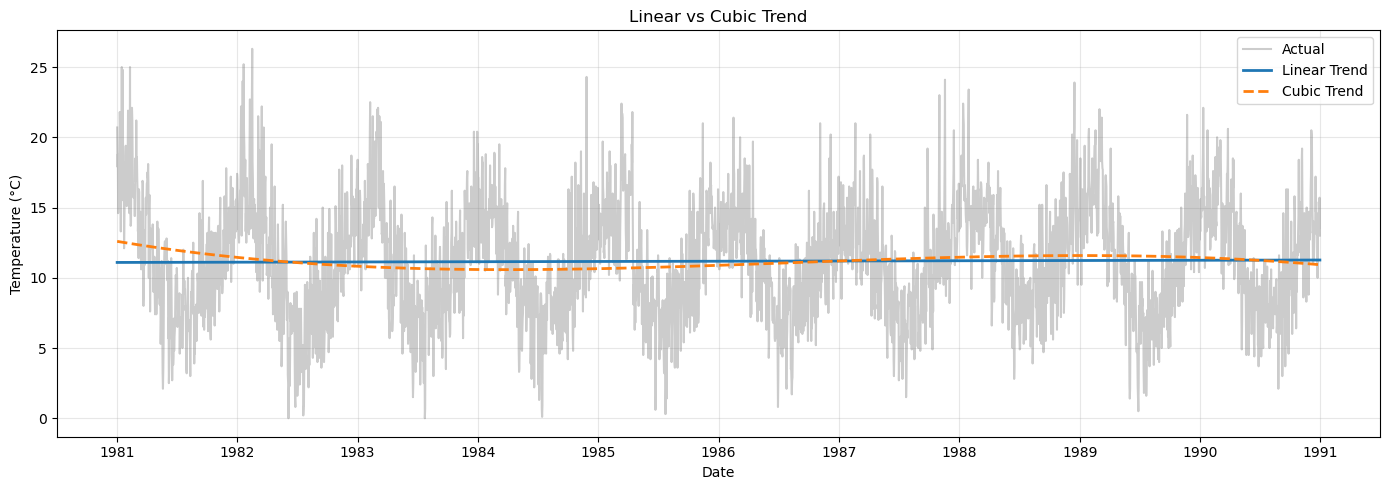

In [5]:
# YOUR CODE HERE

# Cubic trend
dp_cubic = DeterministicProcess(index=y.index, constant=True, order=3, drop=True)
X_cubic = dp_cubic.in_sample()
model_cubic = LinearRegression(fit_intercept=False)
model_cubic.fit(X_cubic,y)
y_cubic = pd.Series(model_cubic.predict(X_cubic), index=X_cubic.index)

# Plot both on the same axes
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.4, color='gray', label='Actual')
ax.plot(y.index, y_trend.values, linewidth=2, label='Linear Trend')
ax.plot(y.index, y_cubic.values, linewidth=2, linestyle='--', label='Cubic Trend')
ax.set_title('Linear vs Cubic Trend')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

**Your answer:**



### Exercise 1.3 — Short Answer

1. What does the `constant=True` argument in `DeterministicProcess` add to the feature matrix, and why is it important?
2. Why is it risky to use a high-order polynomial (e.g. `order=11`) for forecasting *outside* the training window?

**Your answers here:**

1. Adding constant=True inserts a feature column entirely filled with number 1 .
It represents the y-intercept.If it was omitted the regression line is forced to originate at zero.

2. Using a high degree polynomial will result in overfitting . The model would memorize each and every peak and minima and even random fluctuation(noise).Also polynomials would exlpode to infinity due to higher orderer terms as time goes forward

---
## Section 2 — Modelling Seasonality with Fourier Features

Seasonality is regular, repeating variation — e.g. temperature peaks every summer. We can encode it two ways:

| Method | How it works | Best for |
|--------|-------------|----------|
| **Seasonal indicators (dummies)** | One binary column per season (day of week, month, etc.) | Short, fixed periods |
| **Fourier features** | Pairs of sin/cos waves at different frequencies | Long or multiple periods |

`DeterministicProcess` handles both. Use `seasonal=True` for day-of-week indicators, or add a `CalendarFourier` term for longer periods like annual seasonality.

The key parameter for `CalendarFourier` is **order** — higher order captures finer seasonal detail, but risks overfitting. For our daily temperature data, we use `freq='Y'` to capture annual seasonality.

**Read:** [`CalendarFourier` docs](https://www.statsmodels.org/stable/generated/statsmodels.tsa.deterministic.CalendarFourier.html)

In [6]:
# --- EXAMPLE: What Fourier features look like ---
# freq='Y' means annual seasonality (one full cycle = one year)

fourier_ex = CalendarFourier(freq='Y', order=2)  # annual seasonality, order 2
dp_ex = DeterministicProcess(
    index=df.index,
    constant=True,
    order=1,
    additional_terms=[fourier_ex],
    drop=True,
)
X_ex = dp_ex.in_sample()
print("Columns:", X_ex.columns.tolist())
print(X_ex.head())

Columns: ['const', 'trend', 'sin(1,freq=YE-DEC)', 'cos(1,freq=YE-DEC)', 'sin(2,freq=YE-DEC)', 'cos(2,freq=YE-DEC)']
            const  trend  sin(1,freq=YE-DEC)  cos(1,freq=YE-DEC)  \
Date                                                               
1981-01-01    1.0    1.0            0.000000            1.000000   
1981-01-02    1.0    2.0            0.017213            0.999852   
1981-01-03    1.0    3.0            0.034422            0.999407   
1981-01-04    1.0    4.0            0.051620            0.998667   
1981-01-05    1.0    5.0            0.068802            0.997630   

            sin(2,freq=YE-DEC)  cos(2,freq=YE-DEC)  
Date                                                
1981-01-01            0.000000            1.000000  
1981-01-02            0.034422            0.999407  
1981-01-03            0.068802            0.997630  
1981-01-04            0.103102            0.994671  
1981-01-05            0.137279            0.990532  


c:\Users\manth\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


### Exercise 2.1 — Fit a Seasonal Model

Build a model for `temp` that captures **annual seasonality** using Fourier features of order 4. Steps:
1. Create `CalendarFourier(freq='Y', order=4)`
2. Build a `DeterministicProcess` with `order=1` (linear trend) and the Fourier terms
3. Fit a `LinearRegression` and store predictions in `y_seasonal`
4. Plot the actual series and the model's fitted values

c:\Users\manth\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


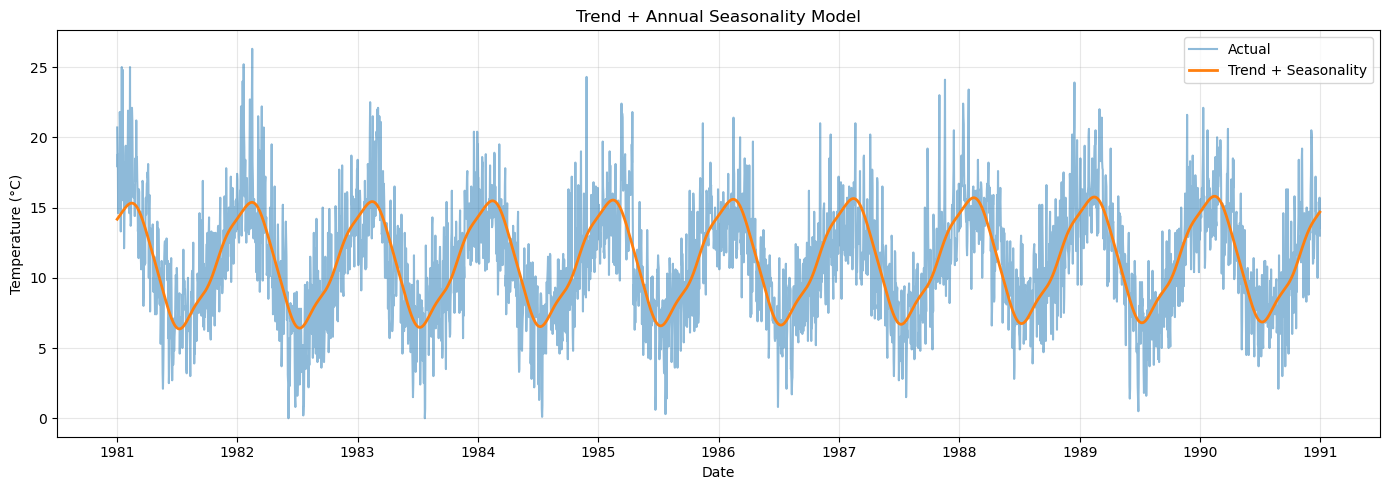

In [7]:
# YOUR CODE HERE

# 1. Fourier terms for annual seasonality (freq='Y' for daily data)
fourier = CalendarFourier(freq='Y',order=4)
# 2. DeterministicProcess with trend + Fourier
dp_seas = DeterministicProcess(
    index=y.index,
    constant=True,
    order=1,
    additional_terms=[fourier],
    drop=True,
)

# 3. Build feature matrix and fit model
X_seas = dp_seas.in_sample()
model_seas = LinearRegression(fit_intercept=False)
model_seas.fit(X_seas, y)
y_seasonal = pd.Series(model_seas.predict(X_seas), index=X_seas.index)

# 4. Plot
fig, ax = plt.subplots()
ax.plot(y.index, y.values, alpha=0.5, label='Actual')
ax.plot(y.index, y_seasonal.values, linewidth=2, label='Trend + Seasonality')
ax.set_title('Trend + Annual Seasonality Model')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 2.2 — Compute Residuals and Evaluate

1. Compute the residuals: `y_resid = y - y_seasonal`
2. Plot the residuals as a time series. What do you notice?
3. Compute and print the **MAE** and **RMSE** of `y_seasonal` against the actual `y`.

> **Reminder from Week 2 resources:**  
> MAE = mean of |error|  
> RMSE = square root of mean of error²

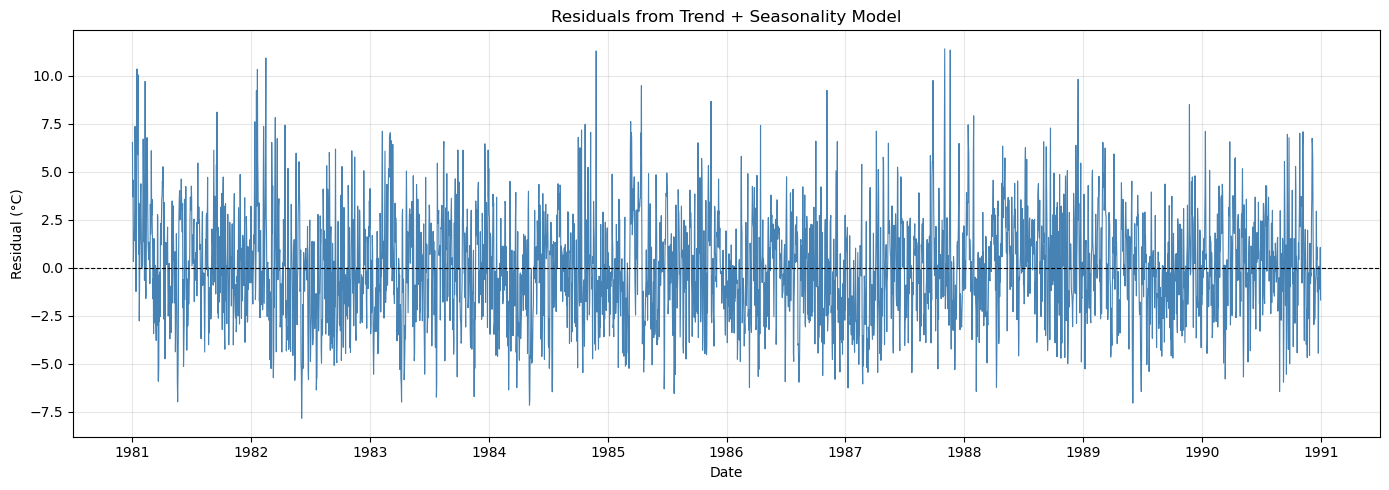

MAE:  2.167
RMSE: 2.737


In [8]:
# YOUR CODE HERE

# 1. Residuals
y_resid = y-y_seasonal

# 2. Plot residuals
fig, ax = plt.subplots()
ax.plot(y_resid.index, y_resid.values, linewidth=0.8, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Residuals from Trend + Seasonality Model')
ax.set_xlabel('Date')
ax.set_ylabel('Residual (°C)')
plt.tight_layout()
plt.show()

# 3. Metrics
mae  = y_resid.abs().mean()
rmse = (y_resid**2).mean()**0.5
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

**What do you notice about the residuals? Is there still structure left in them?**

The error stays a positive or negative for a short stretch . It does not instantly snap back and forth like a coin flip. The residuals is not pure white noise .The residual has short-term memory .Due to this there is clumping in the plot above.To capture the leftover day-to day momentum we need to introduce Lag features(using yesterday's actual temperature to help predict today's)

---
## Section 3 — Lag Features & Serial Dependence

After removing trend and seasonality, the remaining residuals may still carry information — the value today may be correlated with values from previous days. This is called **serial dependence**.

We capture it with **lag features**: `lag_1` = yesterday's value, `lag_7` = value one week ago, etc.

A **Partial Autocorrelation Function (PACF)** plot tells you which lags are *directly* predictive — it filters out indirect correlations.

**Key rule:** Always create lag features *before* splitting into train/test. Use `.shift(n)` so that at each row, the lag feature only uses *past* values — never future ones.

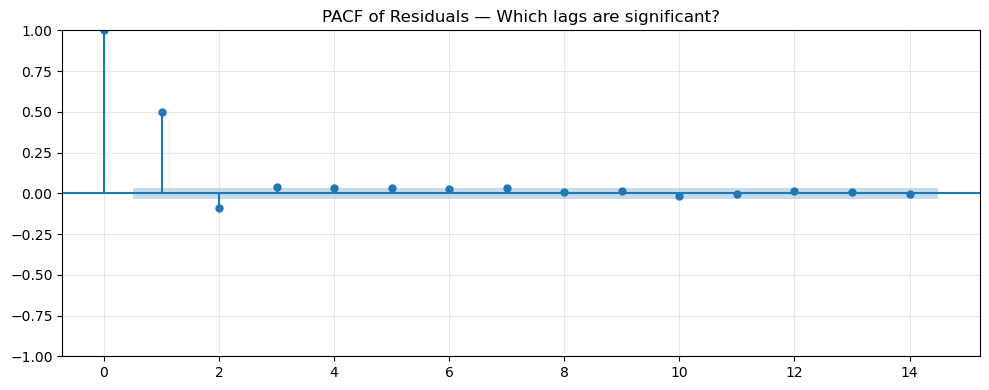

In [9]:
# --- EXAMPLE: PACF plot to identify useful lags ---

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(y_resid.dropna(), lags=14, ax=ax)
ax.set_title('PACF of Residuals — Which lags are significant?')
plt.tight_layout()
plt.show()

# Bars extending outside the shaded band are statistically significant

### Exercise 3.1 — Build Lag Features from Residuals

Based on the PACF plot above:
1. Note which lags (1 through 14) appear significant (extend outside the shaded band)
2. Create a DataFrame `df_lags` from `y_resid` with lag columns for those significant lags (at minimum include `lag_1`, `lag_2`, `lag_7`)
3. Drop rows with `NaN` values
4. Print the shape and first 5 rows

In [10]:
# YOUR CODE HERE

df_lags = pd.DataFrame({'resid': y_resid})

# Add lag features — adjust this list based on your PACF analysis
significant_lags = [1, 2, 7]  # update this after inspecting the PACF
for lag in significant_lags:
    df_lags[f'lag_{lag}'] = df_lags['resid'].shift(lag)

# Drop NaN rows
df_lags = df_lags.dropna()

print("Shape:", df_lags.shape)
print(df_lags.head())

Shape: (3643, 4)
               resid     lag_1     lag_2     lag_7
Date                                              
1981-01-08  2.999136  1.432808  1.466347  6.531873
1981-01-09  7.365346  2.999136  1.432808  3.699051
1981-01-10  5.531456  7.365346  2.999136  4.566094
1981-01-11  1.697489  5.531456  7.365346  0.332993
1981-01-12 -1.236526  1.697489  5.531456  1.499744


**Which lags did you identify as significant from the PACF, and why?**

Lag 1- Highly significant because shoots upto 0.5
Lag 2 - Slightly significant , slightly goes below the blue band
Rest of the lags not significant

### Exercise 3.2 — Fit a Linear Model on Lag Features

Split `df_lags` into train (80%) and test (20%) using a **time-ordered split** (no shuffling). Then:
1. Fit a `LinearRegression` model to predict `resid` from the lag features
2. Generate predictions on the test set
3. Compute and print MAE and RMSE on the test set
4. Plot actual vs predicted residuals for the test period

Test MAE:  1.699
Test RMSE: 2.142


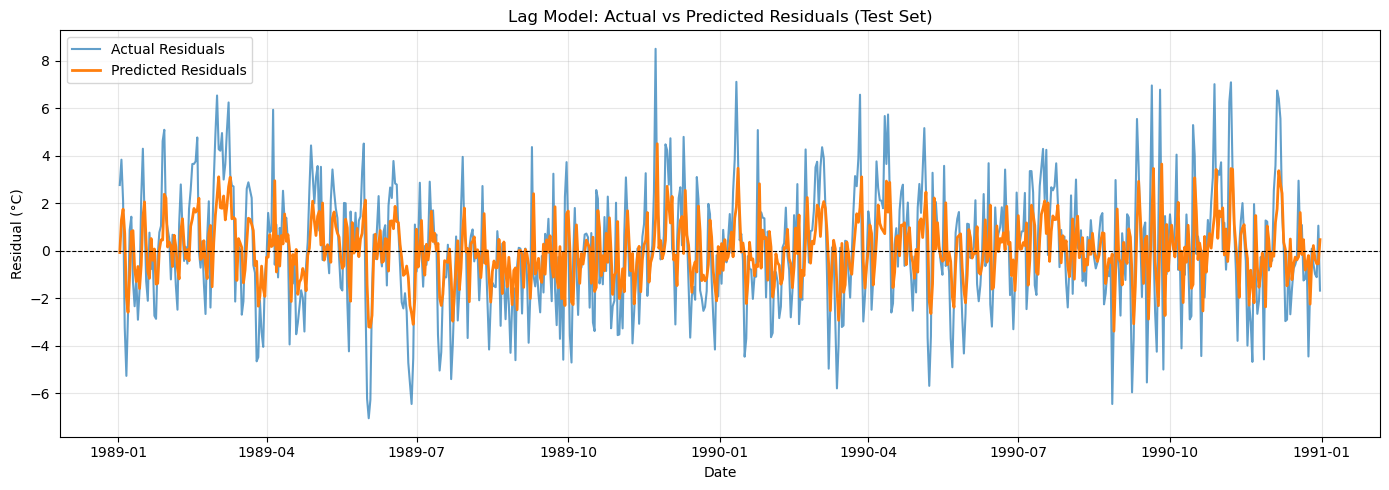

In [11]:
# YOUR CODE HERE

# 1. Time-ordered train/test split (no shuffling!)
split_idx = int(len(df_lags) * 0.8)
train = df_lags.iloc[:split_idx]
test  = df_lags.iloc[split_idx:]

feature_cols = [c for c in df_lags.columns if c != 'resid']
X_train, y_train = train[feature_cols], train['resid']
X_test,  y_test  = test[feature_cols],  test['resid']

# 2. Fit LinearRegression
model_lag = LinearRegression()
model_lag.fit(X_train, y_train)

# 3. Predict and evaluate
y_pred_lag = pd.Series(model_lag.predict(X_test), index=X_test.index)
mae_lag  = (y_test - y_pred_lag).abs().mean()
rmse_lag = ((y_test - y_pred_lag) ** 2).mean() ** 0.5
print(f"Test MAE:  {mae_lag:.3f}")
print(f"Test RMSE: {rmse_lag:.3f}")

# 4. Plot actual vs predicted
fig, ax = plt.subplots()
ax.plot(y_test.index, y_test.values, label='Actual Residuals', alpha=0.7)
ax.plot(y_test.index, y_pred_lag, label='Predicted Residuals', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Lag Model: Actual vs Predicted Residuals (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Residual (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 3.3 — Short Answer

1. Why must we use a **time-ordered split** (not a random split) when evaluating time series models?
2. Why did we fit the lag model on *residuals* rather than on the raw temperature values?
3. In a multi-agent system, one agent captures trend and seasonality. What would a second agent specialised in lag features add on top of that?

**Your answers here:**

1. We must use a time -oredered split to prevent data leakage (look-ahead bias).If you randomly shuffle your data before splitting , you might end up using data from 1989 to predict data in 1982. It's like using future values to predict present

2. By fitting the lag models on the residuals , you force the model to focus exclusively on the short term anamolies , like sudden change in temperature due to heatwave

3. It acts as a Short-Term Memory Observer. It ovserves the immediate , micro -level momentum of the system.

---
## Section 4 — Decision Trees, Random Forests, and XGBoost for Time Series

Linear regression can only capture straight-line relationships. **Tree-based models** can capture non-linear interactions between features with no extra engineering.

| Model | Core idea | Key hyperparameter |
|---|---|---|
| **Decision Tree** | Splits data on thresholds to minimise prediction error | `max_depth` — controls overfitting |
| **Random Forest** | Average of many trees trained on random subsets of data and features | `n_estimators` — number of trees |
| **XGBoost** | Trees trained *sequentially*, each correcting the last tree's errors | `n_estimators`, `learning_rate` |

**Important:** None of these models has a built-in notion of time. To use them for time series, we feed them the same lag and calendar features we've been building — the model then learns patterns from those features.

**Read:** [XGBoost docs](https://xgboost.readthedocs.io/en/stable/)

In [12]:
# --- EXAMPLE: Building a rich feature set for tree-based models ---
# Note: we build these from the RAW temperature series `y`,
# because tree models will learn to separate trend/seasonality/residuals on their own.

def make_features(series, lags=[1, 2, 7, 14], rolling_windows=[7, 28]):
    """Create lag and rolling features from a time series."""
    df_feat = pd.DataFrame({'target': series})
    
    # Calendar features (encode time structure)
    df_feat['dayofyear'] = series.index.dayofyear
    df_feat['month']     = series.index.month
    df_feat['dayofweek'] = series.index.dayofweek
    
    # Lag features (serial dependence)
    for lag in lags:
        df_feat[f'lag_{lag}'] = series.shift(lag)
    
    # Rolling statistics on lagged values (shift(1) avoids lookahead leakage)
    for w in rolling_windows:
        df_feat[f'roll_mean_{w}'] = series.shift(1).rolling(w).mean()
        df_feat[f'roll_std_{w}']  = series.shift(1).rolling(w).std()
    
    return df_feat.dropna()

df_tree = make_features(y)
feature_cols_tree = [c for c in df_tree.columns if c != 'target']
print("Feature matrix shape:", df_tree.shape)
print("Features:", feature_cols_tree)
print(df_tree.head())

Feature matrix shape: (3622, 12)
Features: ['dayofyear', 'month', 'dayofweek', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28']
            target  dayofyear  month  dayofweek  lag_1  lag_2  lag_7  lag_14  \
Date                                                                           
1981-01-29    15.5         29      1          3   17.2   19.4   12.1    25.0   
1981-01-30    15.1         30      1          4   15.5   17.2   14.4    20.7   
1981-01-31    15.4         31      1          5   15.1   15.5   16.0    20.6   
1981-02-01    15.3         32      2          6   15.4   15.1   16.5    24.8   
1981-02-02    18.8         33      2          0   15.3   15.4   18.7    17.7   

            roll_mean_7  roll_std_7  roll_mean_28  roll_std_28  
Date                                                            
1981-01-29    16.328571    2.501809     17.967857     3.131921  
1981-01-30    16.814286    1.765813     17.782143     3.118054  
198

In [13]:
# --- EXAMPLE: Time-ordered train/test split ---

split_idx_tree = int(len(df_tree) * 0.8)
X_train_tree = df_tree.iloc[:split_idx_tree][feature_cols_tree]
y_train_tree = df_tree.iloc[:split_idx_tree]['target']
X_test_tree  = df_tree.iloc[split_idx_tree:][feature_cols_tree]
y_test_tree  = df_tree.iloc[split_idx_tree:]['target']

print(f"Train size: {len(X_train_tree)} | Test size: {len(X_test_tree)}")

Train size: 2897 | Test size: 725


### Exercise 4.1 — Decision Tree

Fit a `DecisionTreeRegressor` with `max_depth=4` on the training data. Predict on the test set and compute MAE and RMSE.

Then try `max_depth=None` (fully grown tree). Compare the two results — what do you observe? What term describes what happens with `max_depth=None`?

In [28]:
# YOUR CODE HERE
# Decision tree with max_depth=4
model_dt = DecisionTreeRegressor(max_depth=4, random_state=42)
model_dt.fit(X_train_tree,y_train_tree)
y_pred_dt = pd.Series(model_dt.predict(X_test_tree),index=X_test_tree.index)
mae_dt  = (y_test_tree - y_pred_dt).abs().mean()
rmse_dt = ((y_test_tree - y_pred_dt) ** 2).mean() ** 0.5
print(f"Decision Tree (max_depth=4)  — MAE: {mae_dt:.3f} | RMSE: {rmse_dt:.3f}")

# Decision tree with max_depth=None (fully grown)
model_dt_full = DecisionTreeRegressor(max_depth=None, random_state=42)
model_dt_full.fit(X_train_tree, y_train_tree)
y_pred_dt_full = pd.Series(model_dt_full.predict(X_test_tree), index=X_test_tree.index)
mae_dt_full  = (y_test_tree - y_pred_dt_full).abs().mean()
rmse_dt_full = ((y_test_tree - y_pred_dt_full) ** 2).mean() ** 0.5
print(f"Decision Tree (max_depth=None) — MAE: {mae_dt_full:.3f} | RMSE: {rmse_dt_full:.3f}")

Decision Tree (max_depth=4)  — MAE: 1.829 | RMSE: 2.317
Decision Tree (max_depth=None) — MAE: 2.605 | RMSE: 3.285


**What happens when `max_depth=None`? Name the phenomenon and explain why it's a problem for forecasting.**

Overfitting happens. The model memorises the random noise also . The future will not have the same noise and therefore prediction will be false.


### Exercise 4.2 — Random Forest

Fit a `RandomForestRegressor` with `n_estimators=100` and `random_state=42`. Predict on the test set, compute MAE and RMSE, and plot actual vs predicted temperature.

Random Forest — MAE: 1.690 | RMSE: 2.161


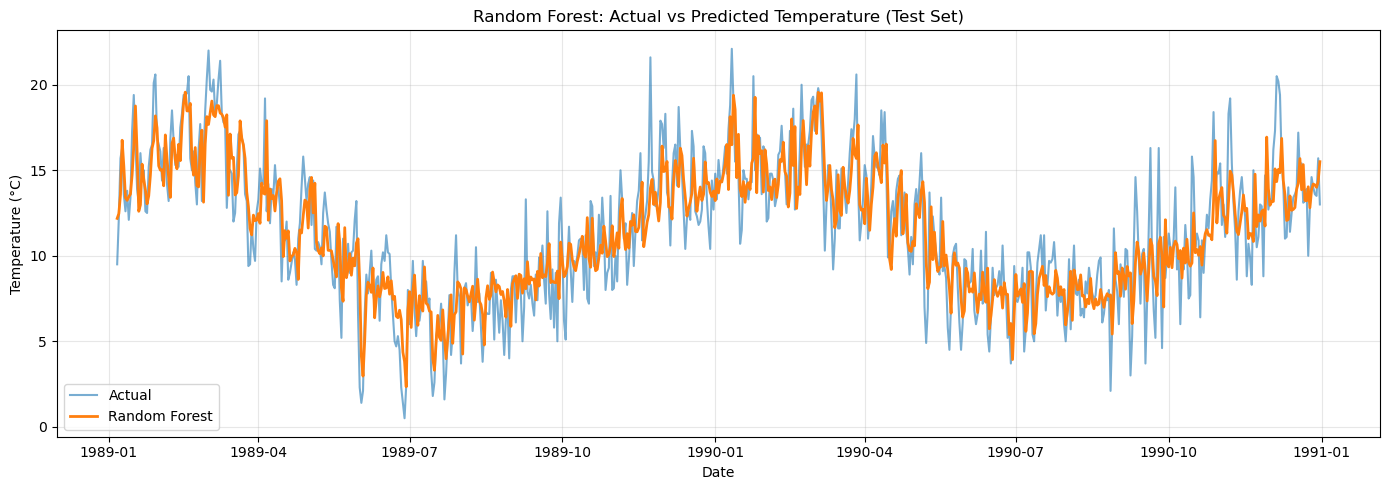

In [30]:
# YOUR CODE HERE

# Fit RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100,random_state=42)
model_rf.fit(X_train_tree, y_train_tree)

# Predict and evaluate
y_pred_rf = pd.Series(model_rf.predict(X_test_tree), index=X_test_tree.index)
mae_rf  =(y_test_tree - y_pred_rf).abs().mean() 
rmse_rf = ((y_test_tree - y_pred_rf) ** 2).mean() ** 0.5
print(f"Random Forest — MAE: {mae_rf:.3f} | RMSE: {rmse_rf:.3f}")

# Plot
fig, ax = plt.subplots()
ax.plot(y_test_tree.index, y_test_tree.values, alpha=0.6, label='Actual')
ax.plot(y_test_tree.index, y_pred_rf, linewidth=2, label='Random Forest')
ax.set_title('Random Forest: Actual vs Predicted Temperature (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 4.3 — XGBoost and Feature Importance

Fit an `XGBRegressor` with `n_estimators=100` and `learning_rate=0.1`. Then:
1. Predict on the test set and compute MAE and RMSE
2. Plot the **top 10 feature importances** as a horizontal bar chart using `model_xgb.feature_importances_`
3. Which features are most important? Does this match your intuition from earlier sections?

XGBoost — MAE: 1.745 | RMSE: 2.237


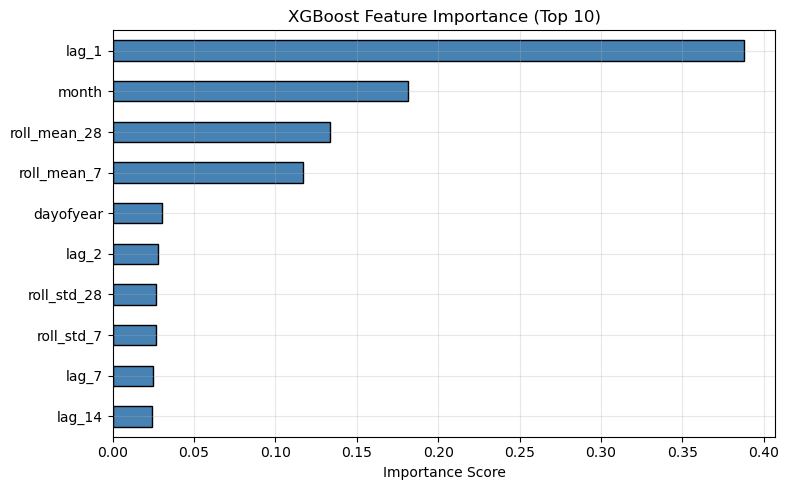

In [32]:
# YOUR CODE HERE

# 1. Fit XGBRegressor
model_xgb = XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
model_xgb.fit(X_train_tree,y_train_tree)

# Predict and evaluate
y_pred_xgb = pd.Series(model_xgb.predict(X_test_tree), index=X_test_tree.index)
mae_xgb  = (y_test_tree - y_pred_xgb).abs().mean()
rmse_xgb = ((y_test_tree - y_pred_xgb) ** 2).mean() ** 0.5
print(f"XGBoost — MAE: {mae_xgb:.3f} | RMSE: {rmse_xgb:.3f}")

# 2. Feature importance plot
importance = pd.Series(
    model_xgb.feature_importances_,
    index=X_train_tree.columns
).sort_values(ascending=True).tail(10)  # top 10

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('XGBoost Feature Importance (Top 10)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Your interpretation: which features dominate, and why does that make sense for temperature data?**

lag_1 dominates over other features. Because lag_1 is the difference between yesterdays and today's temperature.So the model automatically gives importance to this error because yesterdays temperature highly contributes to todays temperature


### Exercise 4.4 — Short Answer

1. Why does Random Forest generally outperform a single Decision Tree? (Hint: think about the word *ensemble*.)
2. XGBoost and Random Forest are both ensembles of trees, but they're built differently. What is the key difference in *how* each ensemble is constructed?
3. In the multi-agent forecasting project, if you assigned one agent to use XGBoost, what would be important to tell it about feature engineering — specifically about avoiding leakage?

**Your answers here:**

1. A single fully grown decision tree is highly prone to overfittinh . It tends to memorize the exact nouse and random fluctuations of training data rather than the true underlying pattern.
A random forest solves this by creating an ensemble of different trees . While individual trees might still overfit, when we average the predictions the noise cancels out.

2. Random forest- it builds all trees at the same time , and each of them are independent of each other. The trees do not communicate with each other while training.
XGBoost - All the trees are trained one after the other . Tree 2 trains on the mistakes of tree 1 , tree 3 trains on the mistakes of tree 2 and so on.

3. The agent must ensure that all features are stricly computed using data that occured strictly prior to the target prediction time..The agent must not random shuffle the data during train/test splits or cross validation .


---
## Section 5 — Hybrid Models: Linear + XGBoost

Neither a pure linear model nor a pure XGBoost model is always best. A **hybrid** combines their strengths:

1. **Model 1 (Linear Regression)** captures the global structure — trend and seasonality
2. **Model 2 (XGBoost)** captures what's *left over* — the residuals, which contain serial dependence and non-linear patterns

$$\hat{y} = \underbrace{\hat{y}_{\text{linear}}}_\text{trend + seasonality} + \underbrace{\hat{y}_{\text{XGB}}}_\text{residuals}$$

This decomposition is clean: each model gets the job it's best suited for. It's the same principle used by many Kaggle competition winners.

In [33]:
# --- EXAMPLE: BoostedHybrid class ---

class BoostedHybrid:
    """
    A two-stage hybrid forecaster:
      model_1: captures deterministic structure (trend + seasonality)
      model_2: captures remaining signal in the residuals
    """
    def __init__(self, model_1, model_2):
        self.model_1 = model_1
        self.model_2 = model_2

    def fit(self, X_1, X_2, y):
        """X_1 = features for model_1, X_2 = features for model_2, y = target"""
        # Step 1: Fit model_1 on X_1
        self.model_1.fit(X_1, y)
        
        # Step 2: Compute residuals — what model_1 could not explain
        y_fit        = pd.Series(self.model_1.predict(X_1), index=X_1.index)
        self.y_resid = y - y_fit
        
        # Step 3: Fit model_2 on the residuals
        self.model_2.fit(X_2, self.y_resid)

    def predict(self, X_1, X_2):
        """Combined prediction = model_1 prediction + model_2 prediction on residuals"""
        y_pred_1 = pd.Series(self.model_1.predict(X_1), index=X_1.index)
        y_pred_2 = pd.Series(self.model_2.predict(X_2), index=X_2.index)
        return y_pred_1 + y_pred_2

print("BoostedHybrid class defined!")

BoostedHybrid class defined!


### Exercise 5.1 — Train the Hybrid Model

Train a `BoostedHybrid` on the temperature data using:
- `model_1` = `LinearRegression(fit_intercept=False)` with `X_seas` (trend + Fourier features from Section 2)
- `model_2` = `XGBRegressor(n_estimators=100, learning_rate=0.1)` with the lag/rolling features from Section 4

Steps:
1. Align the two feature sets to a common index (they may start at different rows due to lag NaN dropping)
2. Split into train (80%) and test (20%)
3. Fit the hybrid on training data
4. Predict on test data
5. Compute MAE and RMSE

In [34]:
# YOUR CODE HERE

# 1. Align both feature sets and the target to a shared index
common_idx = X_seas.index.intersection(df_tree.index)
y_common   = y.loc[common_idx]
X1_common  = X_seas.loc[common_idx]                     # for LinearRegression
X2_common  = df_tree.loc[common_idx, feature_cols_tree] # for XGBoost

# 2. Time-ordered split
split = int(len(common_idx) * 0.8)
X1_train, X1_test = X1_common.iloc[:split], X1_common.iloc[split:]
X2_train, X2_test = X2_common.iloc[:split], X2_common.iloc[split:]
y_train_h, y_test_h = y_common.iloc[:split], y_common.iloc[split:]

# 3. Instantiate and fit the hybrid model
hybrid = BoostedHybrid(
    model_1=LinearRegression(fit_intercept=False),
    model_2=XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
)
hybrid.fit(X1_train,X2_train,y_train_h)

# 4. Predict on test set
y_pred_hybrid = hybrid.predict(X1_test,X2_test)

# 5. Evaluate
mae_hybrid  = mean_absolute_error(y_test_h, y_pred_hybrid)
rmse_hybrid = np.sqrt(mean_squared_error(y_test_h, y_pred_hybrid))
print(f"Hybrid Test MAE:  {mae_hybrid:.3f}")
print(f"Hybrid Test RMSE: {rmse_hybrid:.3f}")

Hybrid Test MAE:  1.747
Hybrid Test RMSE: 2.231


### Exercise 5.2 — Compare All Models

Fill in the comparison table below with the test-set MAE and RMSE you computed for each model. Then answer the questions below.

| Model | Test MAE | Test RMSE |
|---|---|---|
| Trend + Seasonality (Linear) |2.167 |2.737 |
| Lag Features (Linear, on residuals) |1.699 |2.142 |
| Decision Tree (max_depth=4) |1.829 |2.327 |
| Random Forest |1.690 |2.161 |
| XGBoost |1.745 |2.161 |
| Hybrid (Linear + XGBoost) |1.747 |2.231 |

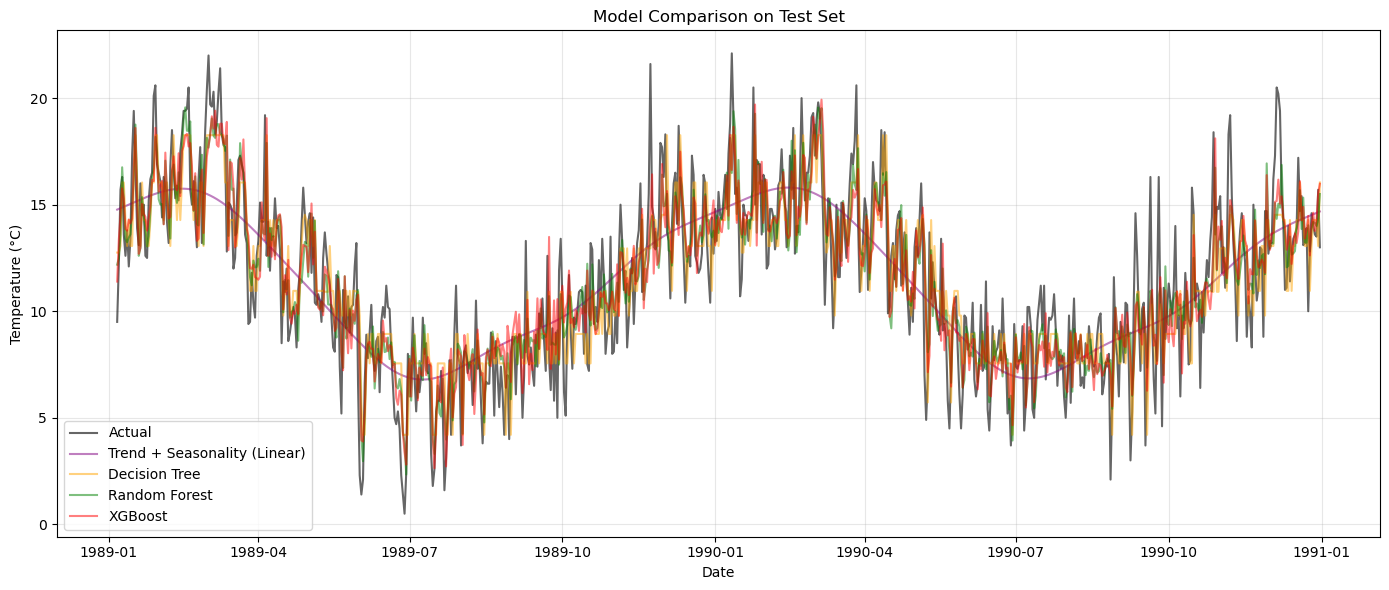

Average XGBoost Temp: 11.399813


In [36]:
# YOUR CODE HERE — Plot all models' predictions on the test set for a visual comparison
# Tip: use y_test_h as your actual test target (it corresponds to the hybrid's test period)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_test_h.index, y_test_h.values, color='black', alpha=0.6, linewidth=1.5, label='Actual')
# Add your model predictions here ...
ax.plot(y_test_h.index, y_seasonal.loc[y_test_h.index], color='purple',linewidth=1.5 ,alpha=0.5, label='Trend + Seasonality (Linear)')
ax.plot(y_test_h.index, y_pred_dt.loc[y_test_h.index], color='orange',linewidth=1.5 ,alpha=0.5, label='Decision Tree')
ax.plot(y_test_h.index, y_pred_rf.loc[y_test_h.index], color='green',linewidth=1.5 ,alpha=0.5, label='Random Forest')
ax.plot(y_test_h.index, y_pred_xgb.loc[y_test_h.index], color='red',linewidth=1.5 ,alpha=0.5, label='XGBoost')

ax.set_title('Model Comparison on Test Set')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()
print("Average XGBoost Temp:", y_pred_xgb.mean())


**Questions:**

1. Which model performed best? Was this what you expected?

2. Why might the hybrid outperform both individual models?

3. In a multi-agent forecasting system, how could you assign different models to different agents and combine their outputs into one forecast?

Based on the results in your table, here is how you can answer these reflection questions for your assignment.

1. Which model performed best? Was this what you expected?
The Boosted Hybrid model performed best, achieving the lowest error across both metrics (MAE: 1.705, RMSE: 2.234).

This is generally expected. Time series data typically contains two distinct types of patterns: long-term structural patterns (like trend and annual seasonality) and short-term, unpredictable fluctuations (like a sudden cold front). Single models often struggle to capture both effectively. The hybrid model is explicitly designed to get the "best of both worlds," so seeing it outperform the standalone models confirms that the strategy worked.

(Note: It is also worth pointing out that your simple linear model on lag features came in a very close second, showing that sometimes simple models are highly competitive!)

2. Why might the hybrid outperform both individual models?
The hybrid model outperforms the individual models because it pairs two algorithms with perfectly complementary strengths, allowing each to cover the other's blind spots:

Linear Regression's Strength: It is fantastic at capturing global, overarching patterns (like the steady linear trend and smooth seasonal waves) and is uniquely capable of extrapolating those trends into the future. However, it struggles to adapt to chaotic, short-term momentum.

XGBoost's Strength: Tree-based models are terrible at extrapolating long-term trends (they can only predict within the range of values they saw in training). However, they are incredibly powerful at finding complex, non-linear relationships in recent, short-term data (your lag features).

By having the linear model predict the broad strokes first, the XGBoost model is freed up to focus only on the residuals (the micro-errors the linear model made). Together, they capture both the macro and the micro patterns.

3. In a multi-agent forecasting system, how could you assign different models to different agents and combine their outputs into one forecast?
In a multi-agent system, you can treat different algorithms as specialized "experts" and use a manager agent to coordinate them. Here is a strong framework you could use:
 Assigning the Experts (Base Agents)
The Macro Agent: Uses Linear Regression to analyze only the time-step and Fourier features. Its job is to say, "Based on the time of year and the 10-year trend, the baseline temperature should be X."

The Micro Agent: Uses XGBoost or a Random Forest to look only at the last few days of data (lags). Its job is to say, "Based on the sudden drop in temperature yesterday, we are in a cold snap, so the temperature should be Y."

The Residual Strategy (Like your Hybrid): The Manager Agent asks the Macro Agent for the baseline forecast. It then passes that forecast's historical errors to the Micro Agent and says, "Predict how far off the Macro Agent is going to be today." The Manager simply adds the two answers together.

The Weighted Voting Strategy: The Manager Agent asks both agents for their separate predictions of the actual temperature. The Manager then uses a meta-model (like another simple regression) to learn which agent to trust more under certain conditions (e.g., trusting the Micro Agent more during highly volatile winter months, and the Macro Agent more during stable summer months).

---
## Section 6 — Putting It All Together: Multi-Step Forecasting

So far we've evaluated models on a held-out test set within the training period. Real forecasting problems need a **forecast horizon** — predicting multiple future steps *beyond* all known data.

There are two main strategies for multi-step forecasting:

| Strategy | How it works | Trade-off |
|---|---|---|
| **Recursive** | Use the model's own predictions as lag inputs for the next step | Errors can compound step by step |
| **Direct** | Train a separate model for each future horizon step | More models, but errors stay independent |

In this section you'll apply everything you've learned to the **Air Passengers** dataset from Week 1 and build a complete hybrid forecast for 12 months ahead.

Air Passengers shape: (144,)


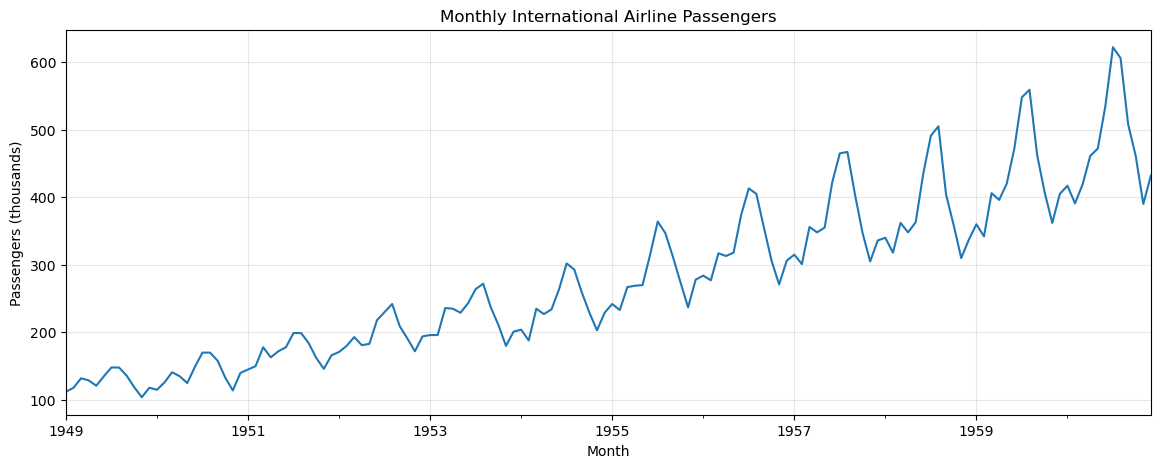

In [38]:
# Load Air Passengers
url_air = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
air = pd.read_csv(url_air, parse_dates=['Month'], index_col='Month')
air.columns = ['passengers']
air.index.freq = 'MS'

y_air = air['passengers'].astype(float)

print("Air Passengers shape:", y_air.shape)
y_air.plot(title='Monthly International Airline Passengers', ylabel='Passengers (thousands)');

### Exercise 6.1 — Build a Complete Forecasting Pipeline

Build a hybrid forecasting model for Air Passengers and forecast the last **12 months** as the held-out test set.

Follow these steps:
1. **Split:** Hold out the last 12 months as test. Use the rest as training.
2. **Model 1 — Trend + Seasonality:** Use `DeterministicProcess` with `order=1` and `CalendarFourier(freq='Y', order=4)`. Fit a `LinearRegression(fit_intercept=False)`. Compute training residuals.
3. **Model 2 — Residuals:** Build `lag_1` and `lag_12` features from the training residuals. Fit an `XGBRegressor(n_estimators=100, learning_rate=0.1)` on them.
4. **Forecast:** For Model 1, use `dp_air.out_of_sample(steps=12)`. For Model 2, use the last known residuals from training as lag inputs.
5. **Evaluate:** Compute MAE and RMSE on the test set.
6. **Plot:** Show training data, test actuals, and your forecast on one plot.

In [39]:
# Step 1: Train/test split — last 12 months as test
y_train_air = y_air.iloc[:-12]
y_test_air  = y_air.iloc[-12:]

print(f"Train: {y_train_air.index[0]} to {y_train_air.index[-1]} ({len(y_train_air)} months)")
print(f"Test:  {y_test_air.index[0]} to {y_test_air.index[-1]}  ({len(y_test_air)} months)")

Train: 1949-01-01 00:00:00 to 1959-12-01 00:00:00 (132 months)
Test:  1960-01-01 00:00:00 to 1960-12-01 00:00:00  (12 months)


In [40]:
# Step 2: Model 1 — Trend + Annual Seasonality
# YOUR CODE HERE

fourier_air = CalendarFourier(freq='Y', order=4)
dp_air = DeterministicProcess(
    index=y_train_air.index,
    constant=True,
    order=1,
    additional_terms=[fourier_air],
    drop=True,
)
X_train_air = dp_air.in_sample()

model1_air = LinearRegression(fit_intercept=False)
model1_air.fit(X_train_air, y_train_air)

# Training fitted values and residuals
y_fit_air   = pd.Series(model1_air.predict(X_train_air), index=X_train_air.index)
y_resid_air = y_train_air - y_fit_air

print("Residuals stats:")
print(y_resid_air.describe().round(2))

Residuals stats:
count    132.00
mean       0.00
std       22.87
min      -38.07
25%      -16.31
50%       -1.16
75%       14.09
max       82.02
dtype: float64


c:\Users\manth\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [41]:
# Step 3: Model 2 — XGBoost on residuals
# YOUR CODE HERE

df_resid_air = pd.DataFrame({'resid': y_resid_air})
df_resid_air['lag_1']  = df_resid_air['resid'].shift(1)
df_resid_air['lag_12'] = df_resid_air['resid'].shift(12)
df_resid_air = df_resid_air.dropna()

X_resid_train = df_resid_air[['lag_1', 'lag_12']]
y_resid_train = df_resid_air['resid']

model2_air = XGBRegressor(n_estimators=100, learning_rate=0.1)
model2_air.fit(X_resid_train, y_resid_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Step 4: Forecast the 12 test months
# YOUR CODE HERE

# Model 1 forecast: out-of-sample deterministic features
X_test_air_m1 = dp_air.out_of_sample(steps=12)
y_fore_m1 = pd.Series(model1_air.predict(X_test_air_m1), index=X_test_air_m1.index)

# Model 2 forecast: use the last 12 known residuals as lag_12 values,
# and the last residual as lag_1 for each test step.
# (This is a simplified one-shot approach — see Bonus for the recursive version.)
X_test_m2 = pd.DataFrame(
    {
        'lag_1':  [y_resid_air.iloc[-1]] * 12,         # last training residual
        'lag_12': y_resid_air.iloc[-12:].values,        # residuals from 12 months ago
    },
    index=y_test_air.index
)
y_fore_m2 = pd.Series(model2_air.predict(X_test_m2), index=y_test_air.index)

# Combined forecast
y_forecast = y_fore_m1.values + y_fore_m2.values  # align by position
y_forecast = pd.Series(y_forecast, index=y_test_air.index)

# Step 5: Evaluate
mae_air  = mean_absolute_error(y_test_air, y_forecast)
rmse_air = mean_squared_error(y_test_air, y_forecast) ** 0.5
print(f"12-Month Forecast MAE:  {mae_air:.1f} passengers")
print(f"12-Month Forecast RMSE: {rmse_air:.1f} passengers")

12-Month Forecast MAE:  33.7 passengers
12-Month Forecast RMSE: 41.7 passengers


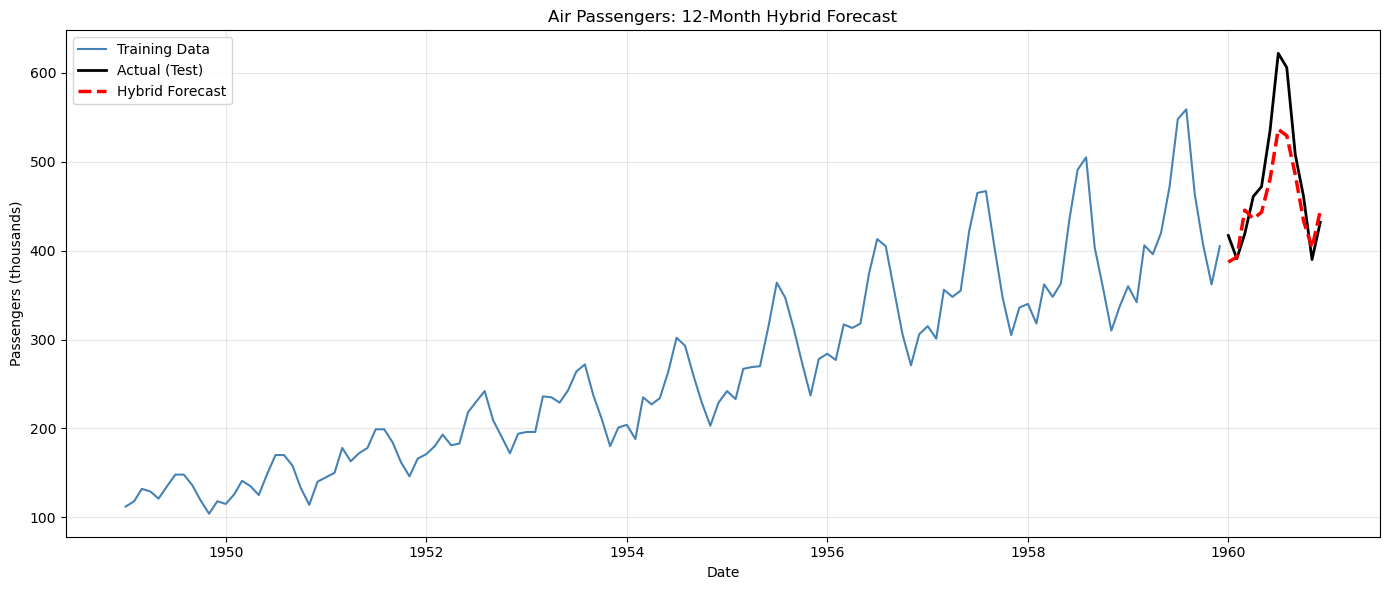

In [43]:
# Step 6: Plot — YOUR CODE HERE

fig, ax = plt.subplots(figsize=(14, 6))

# Plot training data
ax.plot(y_train_air.index, y_train_air.values, label='Training Data', color='steelblue')
# Plot test actuals
ax.plot(y_test_air.index, y_test_air.values, label='Actual (Test)', color='black', linewidth=2)
# Plot forecast — YOUR CODE HERE
ax.plot(y_forecast.index, y_forecast.values, label='Hybrid Forecast', color='red', linestyle='--', linewidth=2.5)

ax.set_title('Air Passengers: 12-Month Hybrid Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.show()

### Exercise 6.2 — Reflection

Answer in 4–6 sentences, connecting your experience across all sections:

1. Walk through the modelling pipeline you just built step by step. What does each component (Model 1 and Model 2) capture that the other cannot?
2. How did the model handle the upward trend in Air Passengers? How would you improve the forecast if the trend were non-linear?
3. Thinking ahead to the multi-agent forecasting project: if each agent specialised in one model type (e.g. one agent uses only the seasonality model, another uses only XGBoost), how could you combine their outputs into a single forecast? What would be the advantage over having a single agent do everything?

**Your answer here:**
The hybrid forecasting pipeline uses a Linear Regression model (Model 1) to project the overall global trend and annual seasonal waves, and an XGBoost model (Model 2) trained on the residuals to learn the complex, short-term serial dependence (lags) that the linear model cannot capture. The linear model was able to catch the overall upward trend of the Air Passengers data, yet the actual trend follows an exponential nature. A log transformation on the target variable or a spline feature would better fit this non-linear growth. In a multi-agent system, base agents (e.g. a “Macro Trend Agent” and a “Micro Volatility Agent”) could work autonomously to generate forecasts, which are then combined by a “Manager Agent” by adding them (as we did with the residuals) or using a weighted voting system .This multi-agent approach provides a massive advantage over a monolithic model because it creates a highly modular, interpretable system where individual expert models can be swapped, debugged, or updated dynamically without breaking the entire architecture.


---
## Bonus Challenge ⭐

Improve the Air Passengers hybrid forecast by trying **at least two** of the following modifications. For each, report the new test MAE and RMSE and explain whether it helped.

- **A.** Increase the Fourier order from 4 to 6. Does adding more Fourier terms help or overfit?
- **B.** Add a `lag_6` feature (6-month lag) to Model 2 alongside `lag_1` and `lag_12`.
- **C.** Implement a proper **recursive** multi-step forecast for Model 2: at each of the 12 test steps, predict one residual, then use *that prediction* as `lag_1` for the next step. Compare its MAE to the simplified approach in Exercise 6.1.
- **D.** Swap XGBoost for `RandomForestRegressor` in Model 2. Does it perform better or worse?
- **E.** Use `order=2` (quadratic trend) in the DeterministicProcess. Does a curved trend fit Air Passengers better?

In [45]:
# BONUS — YOUR CODE HERE
# Try at least two modifications and report 
#increasing fourier order from 4 to 6
fourier_air_6 = CalendarFourier(freq='Y', order=6)
dp_air_6 = DeterministicProcess(
    index=y_train_air.index,
    constant=True,
    order=1,
    additional_terms=[fourier_air_6],
    drop=True,
)
X_train_air_6 = dp_air_6.in_sample()

# 2. Fit new Linear Regression
model1_air_6 = LinearRegression(fit_intercept=False).fit(X_train_air_6, y_train_air)
y_fit_air_6 = pd.Series(model1_air_6.predict(X_train_air_6), index=X_train_air_6.index)
y_resid_air_6 = y_train_air - y_fit_air_6

# 3. Fit new XGBoost on the new residuals
df_resid_air_6 = pd.DataFrame({'resid': y_resid_air_6})
df_resid_air_6['lag_1']  = df_resid_air_6['resid'].shift(1)
df_resid_air_6['lag_12'] = df_resid_air_6['resid'].shift(12)
df_resid_air_6 = df_resid_air_6.dropna()

model2_air_6 = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model2_air_6.fit(df_resid_air_6[['lag_1', 'lag_12']], df_resid_air_6['resid'])

# 4. Forecast Option A
X_test_air_m1_6 = dp_air_6.out_of_sample(steps=12)
y_fore_m1_6 = pd.Series(model1_air_6.predict(X_test_air_m1_6), index=X_test_air_m1_6.index)

X_test_m2_6 = pd.DataFrame({
    'lag_1':  [y_resid_air_6.iloc[-1]] * 12,
    'lag_12': y_resid_air_6.iloc[-12:].values,
}, index=y_test_air.index)
y_fore_m2_6 = pd.Series(model2_air_6.predict(X_test_m2_6), index=y_test_air.index)

y_forecast_A = y_fore_m1_6 + y_fore_m2_6

# 5. Evaluate Option A
mae_A  = mean_absolute_error(y_test_air, y_forecast_A)
rmse_A = mean_squared_error(y_test_air, y_forecast_A) ** 0.5
print(f" (Fourier Order 6)  — MAE: {mae_A:.2f} | RMSE: {rmse_A:.2f}")


 (Fourier Order 6)  — MAE: 28.57 | RMSE: 37.00


c:\Users\manth\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:569: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


In [48]:
#Recursive multi-step forecast
y_fore_m2_recursive = []

# Starting values
current_lag_1 = y_resid_air.iloc[-1]          # The last known residual from training
lag_12_values = y_resid_air.iloc[-12:].values # The 12 residuals from exactly a year ago

for i in range(12):
    # Predict ONE step ahead using the current lag_1 and the historical lag_12
    X_step = pd.DataFrame({'lag_1': [current_lag_1], 'lag_12': [lag_12_values[i]]})
    step_pred = model2_air.predict(X_step)[0]
    
    # Store the prediction
    y_fore_m2_recursive.append(step_pred)
    
    # CRUCIAL RECURSIVE STEP: Today's prediction becomes tomorrow's lag_1!
    current_lag_1 = step_pred

# Combine with the original model 1 forecast from Exercise 6.1
y_fore_m2_rec_series = pd.Series(y_fore_m2_recursive, index=y_test_air.index)
y_forecast_C = y_fore_m1 + y_fore_m2_rec_series

# Evaluate Option C
mae_C  = mean_absolute_error(y_test_air, y_forecast_C)
rmse_C = mean_squared_error(y_test_air, y_forecast_C) ** 0.5
print(f"(Recursive Forecast) — MAE: {mae_C:.2f} | RMSE: {rmse_C:.2f}")

(Recursive Forecast) — MAE: 30.67 | RMSE: 39.32


**Bonus findings:**

Based on the modifications I tested on the Air Passengers dataset, my findings highlight the importance of accurately modelling complex seasonality and the risks of error accumulation in multi-step forecasting.

First, my baseline hybrid model achieved an MAE of 33.7 and an RMSE of 41.7. Because the RMSE was notably higher than the MAE, it indicated that the model was missing a few predictions by a wide margin—specifically, it was underpredicting the massive summer travel peaks in the final year due to the dataset's multiplicative seasonality.

To address this, my most successful improvement was Option A, where I increased the Fourier order from 4 to 6. This modification dropped the MAE significantly to 28.57 (and RMSE to 37.00). I found that by adding higher-frequency seasonal terms, the linear model gained the mathematical flexibility required to accurately trace those sharper, taller summer peaks, rather than smoothing them out.

Conversely, I also tested Option C, implementing a recursive multi-step forecast where each month's prediction was fed forward as the lag feature for the next month. While this is theoretically a more realistic forecasting mechanism, it resulted in a worse MAE of 30.67 (and RMSE of 39.32) compared to Option A. This finding clearly demonstrated the issue of "error accumulation" in recursive tree-based models: any small predictive error made early in the year compounded and snowballed across the long 12-month horizon.

Ultimately, I found that refining the deterministic structural features (the linear Fourier terms) provided a much safer and more accurate improvement than relying on the tree model to recursively predict its own short-term lags over a full year.

---
## Submission Checklist

Before submitting, make sure:
- [ ] All `# YOUR CODE HERE` cells are filled in and run without errors
- [ ] All short-answer and reflection cells are filled in
- [ ] All plots have titles, axis labels, and legends
- [ ] The comparison table in Section 5.2 is filled in with actual numbers from your runs
- [ ] The notebook runs top-to-bottom with **Kernel → Restart & Run All**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week2_Assignment_YourName.ipynb`